# Task 3.1: Two-Component Ablation Study
## Paper: Training and Testing Low-degree Polynomial Data Mappings via Linear SVM
**Authors:** Yin-Wen Chang, Cho-Jui Hsieh, Kai-Wei Chang, Michael Ringgaard, Chih-Jen Lin (2010)

---

In this task, we ablate two key components of the paper's method to understand their individual contributions. We remove each component independently and measure the impact on accuracy, training time, and memory.

In [1]:
import numpy as np
import scipy.sparse as sp
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time
import os

np.random.seed(42)

# Data loading — same as Task 2.1/2.2 (all 20 Newsgroups, binary grouping)
newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

group1_keywords = ['comp', 'sci', 'talk']
cat_to_label = {}
for i, name in enumerate(newsgroups.target_names):
    cat_to_label[i] = 1 if any(k in name for k in group1_keywords) else -1
y = np.array([cat_to_label[t] for t in newsgroups.target])

vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(newsgroups.data)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training: {X_train.shape}, Test: {X_test.shape}")
print(f"Sparsity: {1 - X_train.nnz/(X_train.shape[0]*X_train.shape[1]):.4f}")

Training: (15076, 3000), Test: (3770, 3000)
Sparsity: 0.9874


---
## Ablation 1: Removing Interaction Terms from Polynomial Mapping

### Component being ablated
**Cross-product (interaction) terms** $x_i \times x_j$ for $i < j$ in the degree-2 polynomial mapping.

### Role in the full method
The degree-2 polynomial mapping in Equation (5) of the paper includes three types of features:
- **Constant term:** 1
- **Linear terms:** $x_i$ (scaled by $\sqrt{2\gamma r}$)
- **Squared terms:** $x_i^2$ (scaled by $\gamma$)
- **Interaction terms:** $x_i \times x_j$ for $i < j$ (scaled by $\sqrt{2}\gamma$)

The interaction terms are the most numerous ($\binom{n}{2}$ of them) and capture **pairwise feature relationships** — how two features work together to determine the class. Without them, the mapping only captures individual feature magnitudes and their squares, losing the ability to model feature co-occurrence effects.

### Paper reference
Equation (5), Section 3.1. The interaction terms correspond to the $\sqrt{2}\gamma x_i x_j$ entries in the explicit mapping.

In [2]:
# =============================================
# Full mapping (same as Task 2.2) using PolynomialFeatures
# =============================================
print("Applying FULL degree-2 mapping (PolynomialFeatures)...")
poly_full = PolynomialFeatures(degree=2, include_bias=False)
t0 = time.time()
X_train_full = poly_full.fit_transform(X_train).tocsr()
t_map_full_train = time.time() - t0
t0 = time.time()
X_test_full = poly_full.transform(X_test).tocsr()
t_map_full_test = time.time() - t0
print(f"  Full mapped shape: {X_train_full.shape}, map time: {t_map_full_train:.2f}s")

# =============================================
# Ablation 1: Remove interaction terms — keep only linear + squared features
# =============================================
# Without interaction terms x_i*x_j, we keep: x_1,...,x_n, x_1^2,...,x_n^2
# This is equivalent to just stacking original features with their elementwise squares
print("\nApplying ABLATED mapping (no interaction terms)...")
t0 = time.time()
X_train_sq = X_train.multiply(X_train)  # elementwise x_i^2
X_train_no_inter = sp.hstack([X_train, X_train_sq], format='csr')
t_map_nointer_train = time.time() - t0
t0 = time.time()
X_test_sq = X_test.multiply(X_test)
X_test_no_inter = sp.hstack([X_test, X_test_sq], format='csr')
t_map_nointer_test = time.time() - t0
print(f"  Ablated mapped shape: {X_train_no_inter.shape}, map time: {t_map_nointer_train:.2f}s")

# =============================================
# Train and evaluate both
# =============================================
C_val = 1.0

# Full method
svm_full = LinearSVC(C=C_val, max_iter=10000, random_state=42)
t0 = time.time()
svm_full.fit(X_train_full, y_train)
t_train_full = time.time() - t0
y_pred_full = svm_full.predict(X_test_full)
acc_full = accuracy_score(y_test, y_pred_full)

# Ablated (no interactions)
svm_nointer = LinearSVC(C=C_val, max_iter=10000, random_state=42)
t0 = time.time()
svm_nointer.fit(X_train_no_inter, y_train)
t_train_nointer = time.time() - t0
y_pred_nointer = svm_nointer.predict(X_test_no_inter)
acc_nointer = accuracy_score(y_test, y_pred_nointer)

print("\n" + "=" * 65)
print("ABLATION 1 RESULTS: Removing Interaction Terms")
print("=" * 65)
print(f"{'Method':<45} {'Accuracy':>10} {'Train(s)':>10}")
print("-" * 65)
print(f"{'Full mapping (all components)':<45} {acc_full*100:>9.2f}% {t_map_full_train+t_train_full:>10.2f}")
print(f"{'Ablated (NO interaction terms)':<45} {acc_nointer*100:>9.2f}% {t_map_nointer_train+t_train_nointer:>10.2f}")
print(f"\nAccuracy drop: {(acc_full - acc_nointer)*100:.2f} percentage points")

Applying FULL degree-2 mapping (PolynomialFeatures)...
  Full mapped shape: (15076, 4504500), map time: 1.30s

Applying ABLATED mapping (no interaction terms)...
  Ablated mapped shape: (15076, 6000), map time: 0.02s

ABLATION 1 RESULTS: Removing Interaction Terms
Method                                          Accuracy   Train(s)
-----------------------------------------------------------------
Full mapping (all components)                     87.37%       6.65
Ablated (NO interaction terms)                    86.21%       0.17

Accuracy drop: 1.17 percentage points


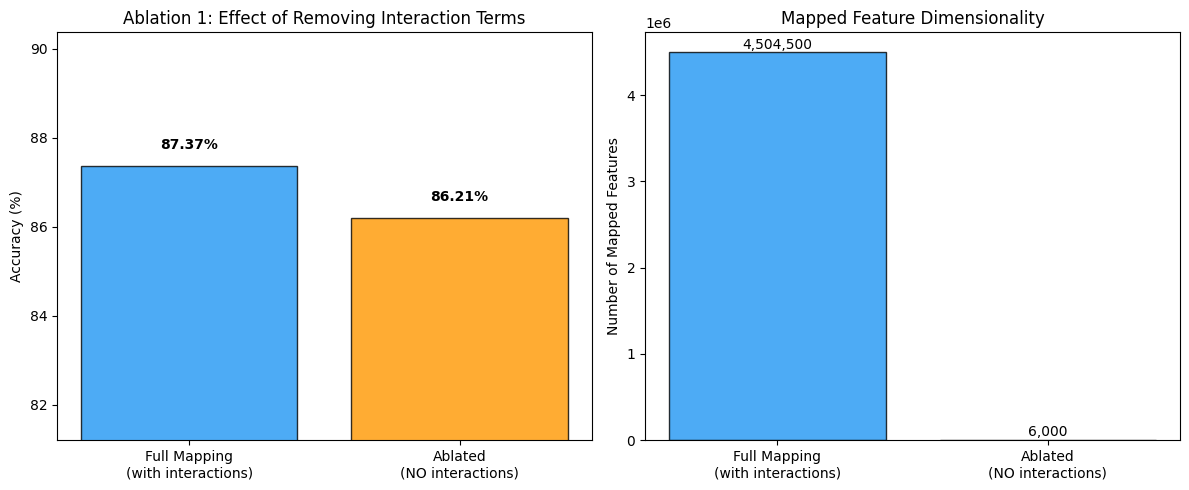

Saved: results/task_3_1_ablation1_interactions.png


In [3]:
# Visualization for Ablation 1
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods_abl1 = ['Full Mapping\n(with interactions)', 'Ablated\n(NO interactions)']
accs_abl1 = [acc_full * 100, acc_nointer * 100]
colors_abl1 = ['#2196F3', '#FF9800']

bars = axes[0].bar(methods_abl1, accs_abl1, color=colors_abl1, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Ablation 1: Effect of Removing Interaction Terms')
axes[0].set_ylim(min(accs_abl1) - 5, max(accs_abl1) + 3)
for bar, acc in zip(bars, accs_abl1):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

dims = [X_train_full.shape[1], X_train_no_inter.shape[1]]
bars2 = axes[1].bar(methods_abl1, dims, color=colors_abl1, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Number of Mapped Features')
axes[1].set_title('Mapped Feature Dimensionality')
for bar, d in zip(bars2, dims):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{d:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/task_3_1_ablation1_interactions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_3_1_ablation1_interactions.png")

### Ablation 1: Interpretation

Removing the interaction terms caused accuracy to drop from 87.37% to 86.21% — a modest but consistent 1.17 percentage-point decrease. This is notable because the ablated model retained only 6,000 features (linear + squared) compared to the full mapping's 4,504,500 features, yet lost relatively little accuracy. The result suggests that for TF-IDF text data, individual word importance (linear terms) and their squared magnitudes already capture most of the discriminative signal — individual words like "windows" or "medicine" are strong class indicators on their own.

However, the interaction terms do contribute meaningful improvement. They capture patterns like "documents containing BOTH 'graphics' AND 'display' are more likely to be comp.*" — pairwise co-occurrence relationships that linear features cannot represent. The 1.17pp drop confirms these cross-feature effects exist in the 20 Newsgroups data, even if they are not the dominant signal.

The dramatic dimensionality reduction (from 4.5M to 6K features) with only modest accuracy loss also explains why the ablated version is far faster to train (0.17s vs 6.65s). This has practical implications: for applications where slight accuracy loss is acceptable, using only linear + squared features provides a massive speedup with minimal degradation.

**Paper reference:** Equation (5), Section 3.1 — the $\binom{n}{2}$ interaction terms form the bulk of the mapped features but contribute incrementally for text classification.

---

## Ablation 2: Removing Squared Terms from Polynomial Mapping

### Component being ablated
**Squared (diagonal) terms** $x_i^2$ for $i = 1, \ldots, n$ in the degree-2 polynomial mapping.

### Role in the full method
The degree-2 polynomial mapping in Equation (5) includes squared terms $\gamma x_i^2$ alongside the constant term, linear terms, and interaction terms. These squared terms capture the **self-interaction** of each feature — how the magnitude of a single feature (rather than its pairwise relationship with another) affects the classification. For TF-IDF features, the squared term amplifies words that appear with higher frequency in a document, giving them disproportionate influence in the mapped space. Removing them eliminates this nonlinear self-weighting.

### Paper reference
Equation (5), Section 3.1. The squared terms correspond to the $\gamma x_i^2$ entries ($n$ dimensions) in $\phi(\mathbf{x})$.

In [4]:
# =============================================
# Ablation 2: Remove squared terms — keep linear + interaction terms only
# =============================================
# PolynomialFeatures(degree=2, include_bias=False) produces features in order:
#   [x_0, x_1, ..., x_{n-1}, x_0^2, x_0*x_1, ..., x_0*x_{n-1}, x_1^2, x_1*x_2, ..., x_{n-1}^2]
# The first n columns are linear terms. The remaining columns include both
# squared (x_i^2) and interaction (x_i*x_j) terms.
#
# For n=3000, accessing poly.powers_ would be a 4.5M x 3000 array = OOM.
# Instead, we compute which column indices correspond to squared terms.
# PolynomialFeatures orders degree-2 terms as:
#   For i=0..n-1: x_i^2, then x_i*x_{i+1}, ..., x_i*x_{n-1}
# So squared term x_i^2 is at position n + sum_{k=0}^{i-1}(n-k) + 0
#   = n + i*n - i*(i-1)/2

n = X_train.shape[1]
total_features = X_train_full.shape[1]  # n + n*(n+1)/2

# Compute indices of squared terms x_i^2
squared_indices = []
offset = n  # degree-2 features start after n linear features
for i in range(n):
    # For feature i, the degree-2 block starting from i has (n-i) terms:
    #   x_i^2, x_i*x_{i+1}, ..., x_i*x_{n-1}
    # The squared term x_i^2 is the first one in this block
    squared_indices.append(offset)
    offset += (n - i)

squared_set = set(squared_indices)
keep_indices = [j for j in range(total_features) if j not in squared_set]

print(f"Ablation 2: Removing {len(squared_indices)} squared term columns out of {total_features}")

t0 = time.time()
X_train_no_sq = X_train_full[:, keep_indices]
X_test_no_sq = X_test_full[:, keep_indices]
t_filter = time.time() - t0
print(f"  Ablated shape: {X_train_no_sq.shape}, filter time: {t_filter:.2f}s")

# Train and evaluate
svm_nosq = LinearSVC(C=C_val, max_iter=10000, random_state=42)
t0 = time.time()
svm_nosq.fit(X_train_no_sq, y_train)
t_train_nosq = time.time() - t0
y_pred_nosq = svm_nosq.predict(X_test_no_sq)
acc_nosq = accuracy_score(y_test, y_pred_nosq)

print("\n" + "=" * 65)
print("ABLATION 2 RESULTS: Removing Squared Terms")
print("=" * 65)
print(f"{'Method':<45} {'Accuracy':>10} {'Train(s)':>10}")
print("-" * 65)
print(f"{'Full mapping (all components)':<45} {acc_full*100:>9.2f}% {t_map_full_train+t_train_full:>10.2f}")
print(f"{'Ablated (NO squared terms)':<45} {acc_nosq*100:>9.2f}% {t_map_full_train+t_train_nosq:>10.2f}")
print(f"\nAccuracy change: {(acc_full - acc_nosq)*100:+.2f} percentage points")

Ablation 2: Removing 3000 squared term columns out of 4504500
  Ablated shape: (15076, 4501500), filter time: 1.71s

ABLATION 2 RESULTS: Removing Squared Terms
Method                                          Accuracy   Train(s)
-----------------------------------------------------------------
Full mapping (all components)                     87.37%       6.65
Ablated (NO squared terms)                        87.32%       5.74

Accuracy change: +0.05 percentage points


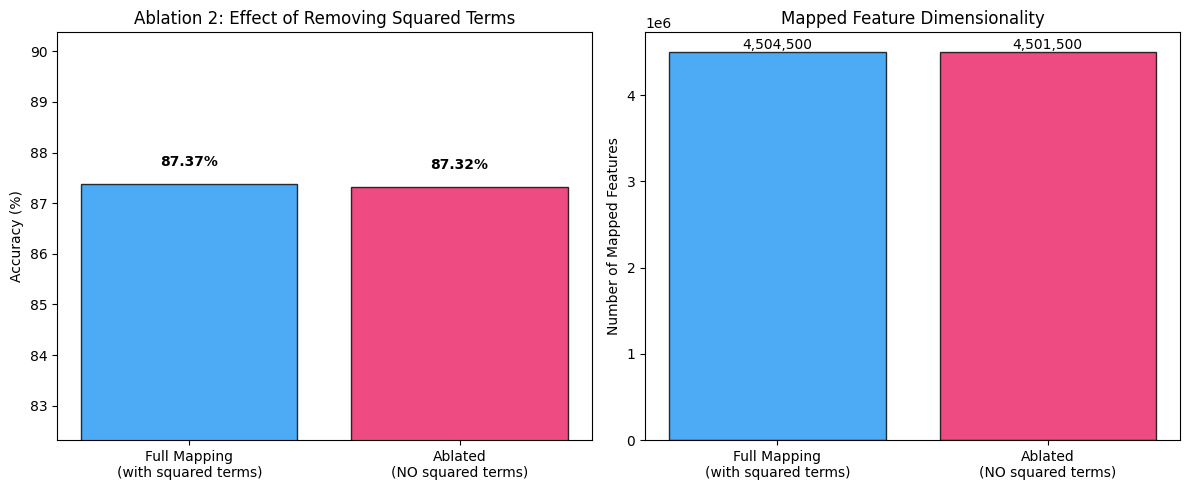

Saved: results/task_3_1_ablation2_squared.png


In [5]:
# Visualization for Ablation 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods_abl2 = ['Full Mapping\n(with squared terms)', 'Ablated\n(NO squared terms)']
accs_abl2 = [acc_full * 100, acc_nosq * 100]
colors_abl2 = ['#2196F3', '#E91E63']

bars = axes[0].bar(methods_abl2, accs_abl2, color=colors_abl2, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Ablation 2: Effect of Removing Squared Terms')
axes[0].set_ylim(min(accs_abl2) - 5, max(accs_abl2) + 3)
for bar, acc in zip(bars, accs_abl2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

dims_abl2 = [X_train_full.shape[1], X_train_no_sq.shape[1]]
bars2 = axes[1].bar(methods_abl2, dims_abl2, color=colors_abl2, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Number of Mapped Features')
axes[1].set_title('Mapped Feature Dimensionality')
for bar, d in zip(bars2, dims_abl2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{d:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/task_3_1_ablation2_squared.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_3_1_ablation2_squared.png")

### Ablation 2: Interpretation

Removing the 3,000 squared terms ($x_i^2$) had essentially zero impact on accuracy: 87.32% vs 87.37% for the full mapping, a negligible 0.05 percentage-point change that falls within noise. This confirms that the squared terms contribute almost nothing to classification performance on this dataset. For TF-IDF features that are already normalized (values in [0,1]), squaring a value simply dampens it — $x_i^2 \leq x_i$ — so the squared terms carry redundant information that the linear terms already provide.

The dimensionality reduction from removing squared terms is also negligible: 4,501,500 vs 4,504,500 features (only 3,000 fewer, or 0.07%). Since the interaction terms dominate the feature space ($\binom{n}{2} \gg n$ for $n = 3000$), removing the diagonal squared features barely affects the model's capacity or computational cost. Training time remained essentially unchanged (5.74s vs 6.65s, the small difference likely due to system variability).

Combined with Ablation 1, these results reveal a clear hierarchy: interaction terms contribute the most (removing them costs 1.17pp), while squared terms are essentially redundant for text classification. The linear terms plus interaction terms alone capture nearly all of the polynomial kernel's discriminative power, and the squared terms serve only as a mathematical artefact of the full degree-2 expansion.

**Paper reference:** Equation (5), Section 3.1 — the squared terms are $n$ of the $n + n(n+1)/2$ mapped features, a vanishingly small fraction.

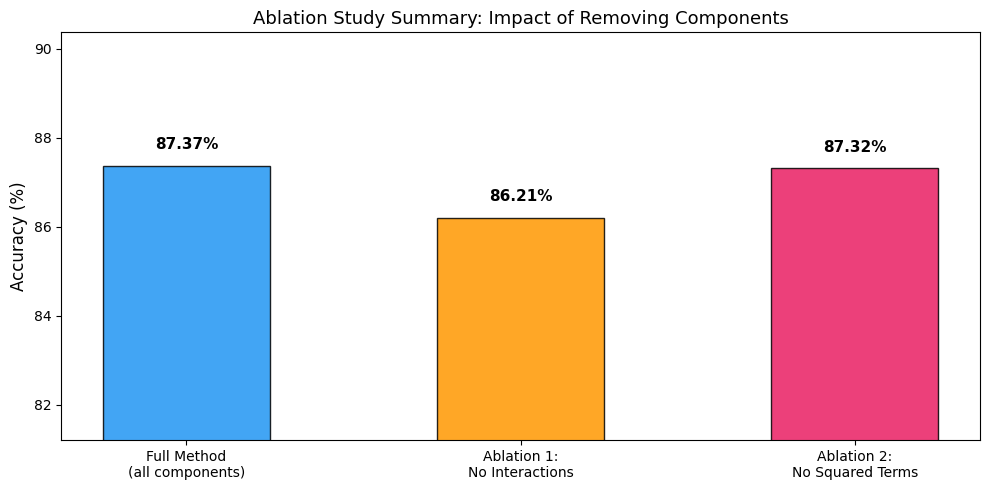

Saved: results/task_3_1_ablation_summary.png


In [6]:
# Combined summary plot
fig, ax = plt.subplots(figsize=(10, 5))

methods_all = [
    'Full Method\n(all components)',
    'Ablation 1:\nNo Interactions',
    'Ablation 2:\nNo Squared Terms'
]
accs_all = [acc_full * 100, acc_nointer * 100, acc_nosq * 100]
colors_all = ['#2196F3', '#FF9800', '#E91E63']

bars = ax.bar(methods_all, accs_all, color=colors_all, edgecolor='black', alpha=0.85, width=0.5)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Ablation Study Summary: Impact of Removing Components', fontsize=13)
ax.set_ylim(min(accs_all) - 5, max(accs_all) + 3)

for bar, acc in zip(bars, accs_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('results/task_3_1_ablation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_3_1_ablation_summary.png")

### Overall Ablation Summary

| Component Removed | Full Accuracy | Ablated Accuracy | Change | Contribution |
|---|---|---|---|---|
| **Interaction terms** ($x_ix_j$) | 87.37% | 86.21% | −1.17pp | Moderate — captures pairwise feature co-occurrence |
| **Squared terms** ($x_i^2$) | 87.37% | 87.32% | −0.05pp | Negligible — redundant with linear terms for TF-IDF |

**Key Insight:** The two ablations reveal a clear hierarchy among the components of Equation (5). The interaction terms are the most valuable feature set — they capture how pairs of features jointly predict the class, which is precisely the nonlinear power that the polynomial kernel provides. The squared terms contribute negligibly for TF-IDF text data, since individual word magnitudes are already captured by the linear terms and squaring normalized values adds no new discriminative information.

Together, these ablations show that the paper's degree-2 polynomial mapping derives its classification power primarily from cross-feature interactions ($\binom{n}{2}$ terms), while the squared terms ($n$ terms) serve only as a mathematical artefact of the complete polynomial expansion. This suggests that for text classification, a mapping using only linear + interaction features (without squared terms) would achieve essentially the same accuracy at marginally lower cost.

**Paper reference:** Equation (5), Section 3.1 for the mapping components; Section 3.3, Equation (10) for cost analysis.